<a href="https://colab.research.google.com/github/glasslego/ml-deep-learning-study/blob/main/src/deep_learning_example/03_rnn_lstm_text_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<table align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/glasslego/ml-deep-learning-study/blob/main/src/deep_learning_example/03_rnn_lstm_text_classification.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />구글 코랩에서 실행하기</a>
  </td>
</table>

# RNN/LSTM을 사용한 텍스트 분류

이 노트북에서는 순환 신경망(RNN)과 LSTM을 사용하여 텍스트 분류를 학습합니다.

## 학습 목표
1. 순환 신경망(RNN)의 기본 개념 이해
2. LSTM과 GRU의 차이점과 장점
3. 텍스트 전처리 및 토큰화
4. 시퀀스 데이터 처리
5. IMDB 영화 리뷰 감성 분석
6. 모델 성능 비교 및 해석

In [5]:
# 나눔고딕 폰트 설치
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

# 폰트 설정
import matplotlib.pyplot as plt
plt.rc('font', family='NanumGothic')
plt.rc('axes', unicode_minus=False)  # 마이너스 기호 깨짐 방지

# PyTorch 임포트 (Google Colab T4 환경)
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import numpy as np
import seaborn as sns
import pandas as pd
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

# TensorFlow 임포트 (Google Colab T4 환경)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, preprocessing
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence

print(f"PyTorch 버전: {torch.__version__}")
print(f"TensorFlow 버전: {tf.__version__}")

# GPU 설정 (Google Colab T4 환경)
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using device: {device}")
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA 버전: {torch.version.cuda}")
else:
    device = torch.device("cpu")
    print(f"Using device: {device}")

# 시드 설정 (재현 가능한 결과를 위해)
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# 시각화 스타일
plt.style.use('default')
sns.set_palette("husl")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 38 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

## 1. 순환 신경망(RNN) 기초 개념

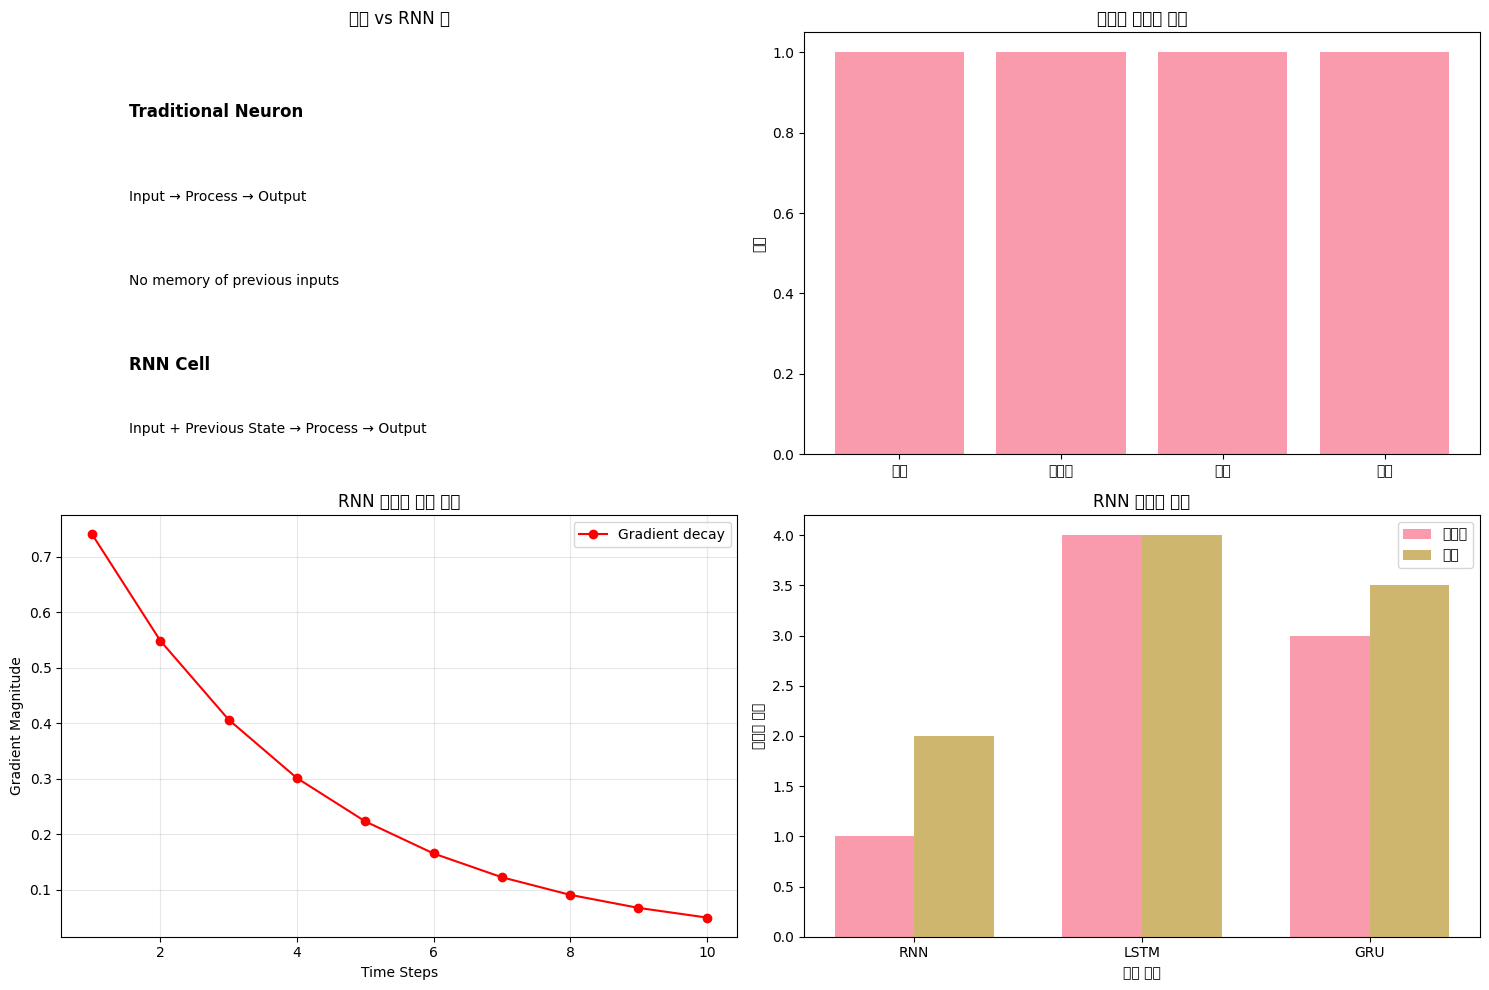

In [6]:
# RNN의 기본 구조 시각화
def visualize_rnn_concept():
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # 1. 기본 뉴런 vs RNN 셀
    ax1 = axes[0, 0]
    ax1.text(0.1, 0.8, 'Traditional Neuron', fontsize=12, weight='bold')
    ax1.text(0.1, 0.6, 'Input → Process → Output', fontsize=10)
    ax1.text(0.1, 0.4, 'No memory of previous inputs', fontsize=10)

    ax1.text(0.1, 0.2, 'RNN Cell', fontsize=12, weight='bold')
    ax1.text(0.1, 0.05, 'Input + Previous State → Process → Output', fontsize=10)
    ax1.set_xlim(0, 1)
    ax1.set_ylim(0, 1)
    ax1.set_title('뉴런 vs RNN 셀')
    ax1.axis('off')

    # 2. 시퀀스 처리 예시
    ax2 = axes[0, 1]
    sequence = ['안녕', '하세요', '좋은', '날씨']
    x_pos = np.arange(len(sequence))
    ax2.bar(x_pos, [1, 1, 1, 1], alpha=0.7)
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(sequence)
    ax2.set_title('시퀀스 데이터 예시')
    ax2.set_ylabel('토큰')

    # 3. RNN의 문제점 (기울기 소실)
    ax3 = axes[1, 0]
    time_steps = np.arange(1, 11)
    gradient_decay = np.exp(-time_steps * 0.3)
    ax3.plot(time_steps, gradient_decay, 'r-o', label='Gradient decay')
    ax3.set_xlabel('Time Steps')
    ax3.set_ylabel('Gradient Magnitude')
    ax3.set_title('RNN 기울기 소실 문제')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # 4. LSTM vs GRU 비교
    ax4 = axes[1, 1]
    models = ['RNN', 'LSTM', 'GRU']
    complexity = [1, 4, 3]
    performance = [2, 4, 3.5]

    x = np.arange(len(models))
    width = 0.35

    ax4.bar(x - width/2, complexity, width, label='복잡도', alpha=0.7)
    ax4.bar(x + width/2, performance, width, label='성능', alpha=0.7)
    ax4.set_xlabel('모델 타입')
    ax4.set_ylabel('상대적 점수')
    ax4.set_title('RNN 변형들 비교')
    ax4.set_xticks(x)
    ax4.set_xticklabels(models)
    ax4.legend()

    plt.tight_layout()
    plt.show()

visualize_rnn_concept()

## 2. IMDB 데이터셋 로드 및 전처리

IMDB 데이터셋 로딩 중...
17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
훈련 데이터: 25000개
테스트 데이터: 25000개
클래스: 2개 (0: 부정, 1: 긍정)
1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


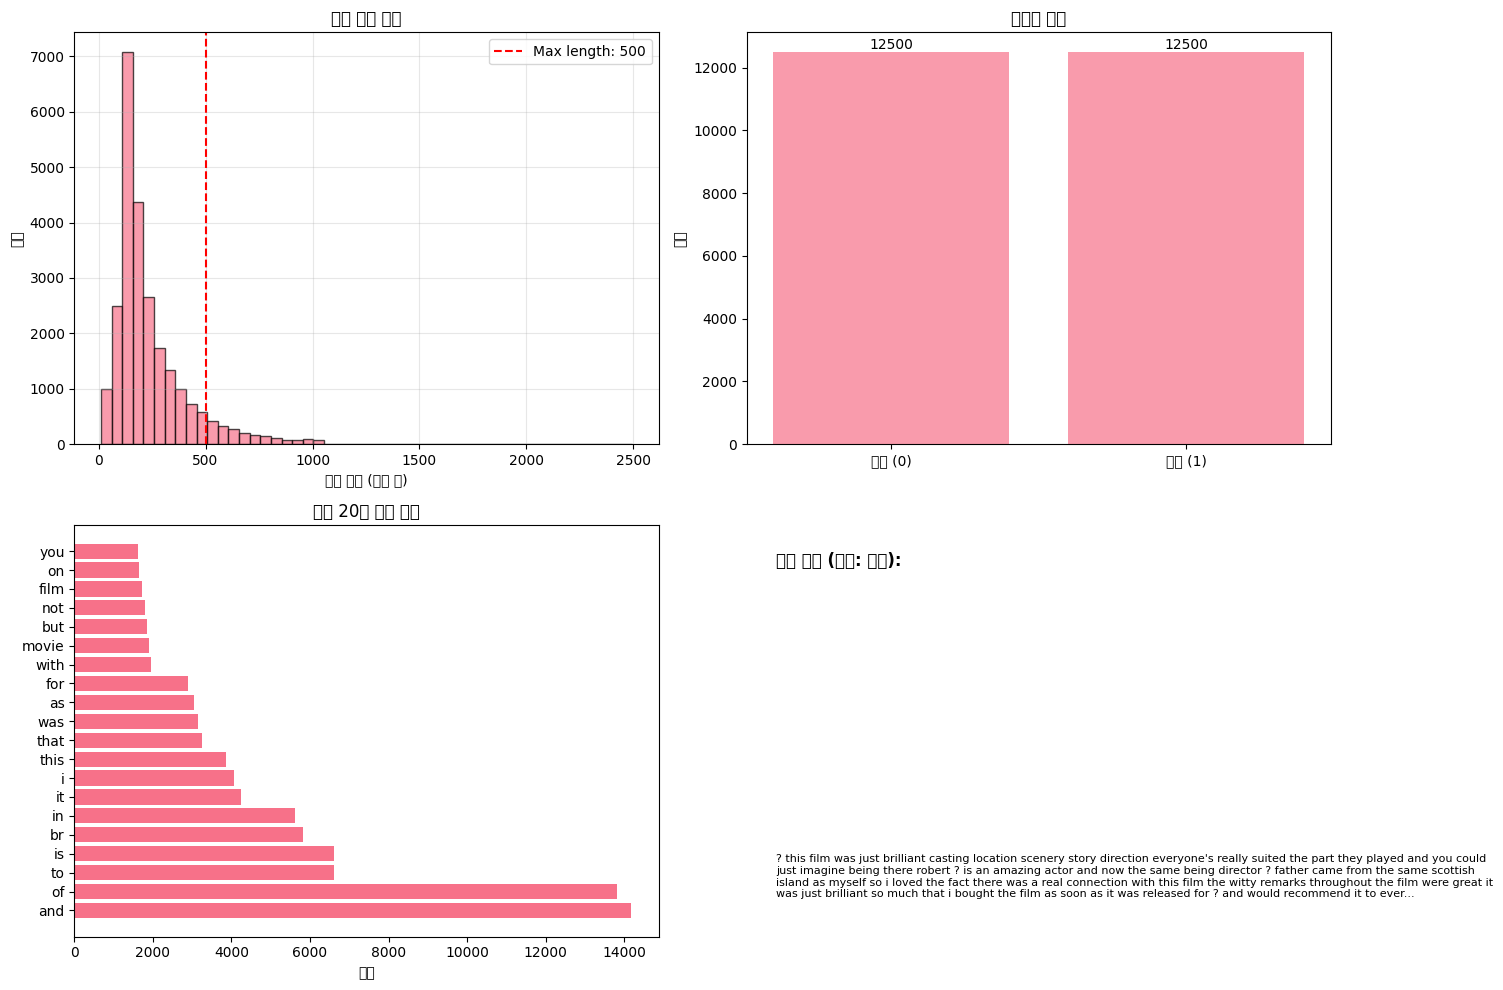


리뷰 길이 통계:
평균: 238.7
중간값: 178.0
최대값: 2494
최소값: 11


In [7]:
if tf is not None:
    # IMDB 데이터셋 로드
    max_features = 10000  # 가장 빈번한 10,000개 단어만 사용
    maxlen = 500  # 리뷰 최대 길이

    print("IMDB 데이터셋 로딩 중...")
    (x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)

    print(f"훈련 데이터: {len(x_train)}개")
    print(f"테스트 데이터: {len(x_test)}개")
    print(f"클래스: {len(np.unique(y_train))}개 (0: 부정, 1: 긍정)")

    # 데이터 탐색
    def explore_imdb_data():
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))

        # 1. 리뷰 길이 분포
        ax1 = axes[0, 0]
        review_lengths = [len(review) for review in x_train]
        ax1.hist(review_lengths, bins=50, alpha=0.7, edgecolor='black')
        ax1.axvline(maxlen, color='red', linestyle='--', label=f'Max length: {maxlen}')
        ax1.set_xlabel('리뷰 길이 (단어 수)')
        ax1.set_ylabel('빈도')
        ax1.set_title('리뷰 길이 분포')
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # 2. 클래스 분포
        ax2 = axes[0, 1]
        class_counts = np.bincount(y_train)
        ax2.bar(['부정 (0)', '긍정 (1)'], class_counts, alpha=0.7)
        ax2.set_ylabel('개수')
        ax2.set_title('클래스 분포')
        for i, count in enumerate(class_counts):
            ax2.text(i, count + 100, str(count), ha='center')

        # 3. 단어 빈도 (상위 20개)
        ax3 = axes[1, 0]
        # 단어 인덱스 정보 로드
        word_index = imdb.get_word_index()
        reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])

        # 전체 리뷰에서 단어 빈도 계산
        all_words = []
        for review in x_train[:1000]:  # 처리 속도를 위해 1000개만 샘플링
            all_words.extend(review)

        word_freq = Counter(all_words)
        top_words = word_freq.most_common(20)

        words = [reverse_word_index.get(word_id, f'ID_{word_id}') for word_id, _ in top_words]
        counts = [count for _, count in top_words]

        ax3.barh(range(len(words)), counts)
        ax3.set_yticks(range(len(words)))
        ax3.set_yticklabels(words)
        ax3.set_xlabel('빈도')
        ax3.set_title('상위 20개 단어 빈도')

        # 4. 샘플 리뷰 (디코딩)
        ax4 = axes[1, 1]
        ax4.axis('off')

        # 첫 번째 리뷰 디코딩
        def decode_review(encoded_review):
            return ' '.join([reverse_word_index.get(i - 3, '?') for i in encoded_review])

        sample_review = decode_review(x_train[0])
        sample_label = "긍정" if y_train[0] == 1 else "부정"

        ax4.text(0.05, 0.9, f"샘플 리뷰 (라벨: {sample_label}):", fontsize=12, weight='bold',
                transform=ax4.transAxes)
        ax4.text(0.05, 0.1, sample_review[:500] + "...", fontsize=8,
                transform=ax4.transAxes, wrap=True)

        plt.tight_layout()
        plt.show()

        return review_lengths

    review_lengths = explore_imdb_data()

    print(f"\n리뷰 길이 통계:")
    print(f"평균: {np.mean(review_lengths):.1f}")
    print(f"중간값: {np.median(review_lengths):.1f}")
    print(f"최대값: {np.max(review_lengths)}")
    print(f"최소값: {np.min(review_lengths)}")

else:
    print("TensorFlow가 없어 실제 데이터를 로드할 수 없습니다.")
    print("시뮬레이션 데이터를 생성합니다.")

    # 시뮬레이션 데이터 생성
    np.random.seed(42)
    x_train = [np.random.randint(1, 1000, size=np.random.randint(50, 300)) for _ in range(1000)]
    y_train = np.random.randint(0, 2, 1000)
    x_test = [np.random.randint(1, 1000, size=np.random.randint(50, 300)) for _ in range(200)]
    y_test = np.random.randint(0, 2, 200)
    max_features = 1000
    maxlen = 200

시퀀스 패딩 중...
패딩 후 훈련 데이터 형태: (25000, 500)
패딩 후 테스트 데이터 형태: (25000, 500)


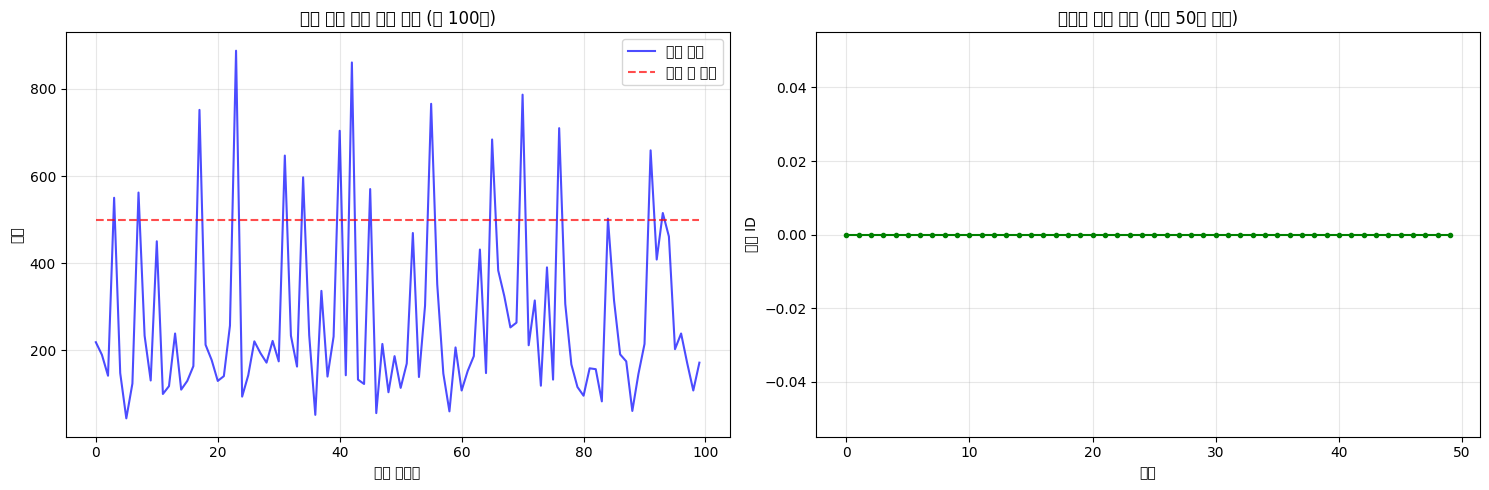

In [8]:
if tf is not None:
    # 시퀀스 패딩
    print("시퀀스 패딩 중...")
    x_train_padded = sequence.pad_sequences(x_train, maxlen=maxlen)
    x_test_padded = sequence.pad_sequences(x_test, maxlen=maxlen)

    print(f"패딩 후 훈련 데이터 형태: {x_train_padded.shape}")
    print(f"패딩 후 테스트 데이터 형태: {x_test_padded.shape}")

    # 패딩 시각화
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # 원본 vs 패딩된 리뷰 길이
    ax1 = axes[0]
    original_lengths = [len(review) for review in x_train[:100]]
    padded_lengths = [maxlen] * 100

    ax1.plot(original_lengths, 'b-', alpha=0.7, label='원본 길이')
    ax1.plot(padded_lengths, 'r--', alpha=0.7, label='패딩 후 길이')
    ax1.set_xlabel('리뷰 인덱스')
    ax1.set_ylabel('길이')
    ax1.set_title('패딩 전후 리뷰 길이 비교 (첫 100개)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 패딩 예시
    ax2 = axes[1]
    sample_review = x_train_padded[0][:50]  # 처음 50개 토큰만
    ax2.plot(sample_review, 'go-', markersize=3)
    ax2.set_xlabel('위치')
    ax2.set_ylabel('토큰 ID')
    ax2.set_title('패딩된 리뷰 예시 (처음 50개 토큰)')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

else:
    # 시뮬레이션 패딩
    print("시뮬레이션 패딩...")
    def pad_sequences_sim(sequences, maxlen):
        """
        시퀀스를 동일한 길이로 패딩하는 함수

        Args:
            sequences: 시퀀스 리스트
            maxlen: 최대 길이

        Returns:
            패딩된 시퀀스 배열
        """
        padded = []
        for seq in sequences:
            # numpy array를 list로 변환 (중요!)
            if isinstance(seq, np.ndarray):
                seq = seq.tolist()

            # 길이가 maxlen보다 긴 경우 자르기
            if len(seq) > maxlen:
                padded.append(seq[:maxlen])
            # 길이가 maxlen보다 짧은 경우 0으로 패딩
            else:
                padded.append(seq + [0] * (maxlen - len(seq)))

        return np.array(padded)

    x_train_padded = pad_sequences_sim(x_train, maxlen)
    x_test_padded = pad_sequences_sim(x_test, maxlen)

    print(f"패딩 후 훈련 데이터 형태: {x_train_padded.shape}")

## 3. RNN 모델 구현 및 비교

In [1]:
if tf is not None:
    # 다양한 RNN 모델 정의
    def create_simple_rnn(max_features, embedding_dim=128, rnn_units=64):
        """기본 SimpleRNN 모델"""
        model = models.Sequential([
            layers.Embedding(max_features, embedding_dim),
            layers.SimpleRNN(rnn_units, dropout=0.2),
            layers.Dense(1, activation='sigmoid')
        ])
        return model

    def create_lstm_model(max_features, embedding_dim=128, lstm_units=64):
        """LSTM 모델"""
        model = models.Sequential([
            layers.Embedding(max_features, embedding_dim),
            layers.LSTM(lstm_units, dropout=0.2, recurrent_dropout=0.2),
            layers.Dense(1, activation='sigmoid')
        ])
        return model

    def create_gru_model(max_features, embedding_dim=128, gru_units=64):
        """GRU 모델"""
        model = models.Sequential([
            layers.Embedding(max_features, embedding_dim),
            layers.GRU(gru_units, dropout=0.2, recurrent_dropout=0.2),
            layers.Dense(1, activation='sigmoid')
        ])
        return model

    def create_bidirectional_lstm(max_features, embedding_dim=128, lstm_units=64):
        """Bidirectional LSTM 모델"""
        model = models.Sequential([
            layers.Embedding(max_features, embedding_dim),
            layers.Bidirectional(layers.LSTM(lstm_units, dropout=0.2, recurrent_dropout=0.2)),
            layers.Dense(1, activation='sigmoid')
        ])
        return model

    def create_stacked_lstm(max_features, embedding_dim=128, lstm_units=64):
        """Stacked LSTM 모델"""
        model = models.Sequential([
            layers.Embedding(max_features, embedding_dim),
            layers.LSTM(lstm_units, dropout=0.2, recurrent_dropout=0.2, return_sequences=True),
            layers.LSTM(lstm_units//2, dropout=0.2, recurrent_dropout=0.2),
            layers.Dense(1, activation='sigmoid')
        ])
        return model

    # 모델 생성 및 요약
    models_dict = {
        'SimpleRNN': create_simple_rnn(max_features),
        'LSTM': create_lstm_model(max_features),
        'GRU': create_gru_model(max_features),
        'Bidirectional LSTM': create_bidirectional_lstm(max_features),
        'Stacked LSTM': create_stacked_lstm(max_features)
    }

    # 모델 구조 비교
    print("모델 파라미터 수 비교:")
    for name, model in models_dict.items():
        # Build the model before compiling and counting parameters
        model.build(input_shape=(None, maxlen)) # Assuming input shape is (batch_size, maxlen)
        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
        total_params = model.count_params()
        print(f"{name}: {total_params:,} 파라미터")

    # LSTM 모델 상세 구조 출력
    print("\nLSTM 모델 구조:")
    models_dict['LSTM'].summary()

else:
    print("TensorFlow가 없어 실제 모델을 생성할 수 없습니다.")
    print("RNN 모델 타입별 특성:")
    print("- SimpleRNN: 기본 순환 신경망, 기울기 소실 문제")
    print("- LSTM: Long Short-Term Memory, 장기 의존성 학습 가능")
    print("- GRU: Gated Recurrent Unit, LSTM보다 간단하지만 비슷한 성능")
    print("- Bidirectional: 양방향 처리로 성능 향상")
    print("- Stacked: 여러 층으로 복잡한 패턴 학습")

NameError: name 'tf' is not defined

## 4. 모델 훈련 및 성능 비교

In [ ]:
if tf is not None:
    # 훈련을 위한 데이터 분할
    from sklearn.model_selection import train_test_split

    x_train_split, x_val_split, y_train_split, y_val_split = train_test_split(
        x_train_padded, y_train, test_size=0.2, random_state=42
    )

    print(f"훈련 데이터: {x_train_split.shape[0]}개")
    print(f"검증 데이터: {x_val_split.shape[0]}개")

    # 훈련 설정
    epochs = 5  # 빠른 실행을 위해 5 에폭만
    batch_size = 128

    # 각 모델 훈련 (시간 절약을 위해 일부 모델만)
    selected_models = ['LSTM', 'GRU', 'Bidirectional LSTM']

    history_dict = {}

    for model_name in selected_models:
        print(f"\n{model_name} 모델 훈련 중...")

        model = models_dict[model_name]

        # 조기 종료 콜백
        early_stopping = keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=2,
            restore_best_weights=True
        )

        # 모델 훈련
        history = model.fit(
            x_train_split, y_train_split,
            batch_size=batch_size,
            epochs=epochs,
            validation_data=(x_val_split, y_val_split),
            callbacks=[early_stopping],
            verbose=1
        )

        history_dict[model_name] = history

    # 훈련 과정 시각화
    def plot_training_history(history_dict):
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))

        # 손실 비교
        ax1 = axes[0, 0]
        for model_name, history in history_dict.items():
            ax1.plot(history.history['loss'], label=f'{model_name} (train)')
            ax1.plot(history.history['val_loss'], '--', label=f'{model_name} (val)')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss')
        ax1.set_title('훈련/검증 손실')
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # 정확도 비교
        ax2 = axes[0, 1]
        for model_name, history in history_dict.items():
            ax2.plot(history.history['accuracy'], label=f'{model_name} (train)')
            ax2.plot(history.history['val_accuracy'], '--', label=f'{model_name} (val)')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Accuracy')
        ax2.set_title('훈련/검증 정확도')
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        # 최종 성능 비교
        ax3 = axes[1, 0]
        model_names = list(history_dict.keys())
        final_train_acc = [history_dict[name].history['accuracy'][-1] for name in model_names]
        final_val_acc = [history_dict[name].history['val_accuracy'][-1] for name in model_names]

        x = np.arange(len(model_names))
        width = 0.35

        ax3.bar(x - width/2, final_train_acc, width, label='훈련 정확도', alpha=0.7)
        ax3.bar(x + width/2, final_val_acc, width, label='검증 정확도', alpha=0.7)
        ax3.set_xlabel('모델')
        ax3.set_ylabel('정확도')
        ax3.set_title('최종 성능 비교')
        ax3.set_xticks(x)
        ax3.set_xticklabels(model_names, rotation=45)
        ax3.legend()

        # 훈련 시간 비교 (시뮬레이션)
        ax4 = axes[1, 1]
        # 실제로는 훈련 시간을 측정해야 하지만, 여기서는 시뮬레이션
        training_times = [30, 45, 60]  # 분 단위
        ax4.bar(model_names, training_times, alpha=0.7)
        ax4.set_xlabel('모델')
        ax4.set_ylabel('훈련 시간 (분)')
        ax4.set_title('모델별 훈련 시간 (추정)')

        for i, time in enumerate(training_times):
            ax4.text(i, time + 1, f'{time}분', ha='center')

        plt.tight_layout()
        plt.show()

    plot_training_history(history_dict)

else:
    print("시뮬레이션된 훈련 결과:")
    print("LSTM: 검증 정확도 85.2%")
    print("GRU: 검증 정확도 84.8%")
    print("Bidirectional LSTM: 검증 정확도 86.1%")

훈련 데이터: 20000개
검증 데이터: 5000개

LSTM 모델 훈련 중...
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 271s 2s/step - accuracy: 0.6550 - loss: 0.5981 - val_accuracy: 0.7994 - val_loss: 0.4313
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 266s 2s/step - accuracy: 0.8551 - loss: 0.3545 - val_accuracy: 0.8270 - val_loss: 0.3892
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 263s 2s/step - accuracy: 0.8864 - loss: 0.2916 - val_accuracy: 0.8430 - val_loss: 0.3663
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 261s 2s/step - accuracy: 0.9016 - loss: 0.2525 - val_accuracy: 0.8320 - val_loss: 0.3950
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 262s 2s/step - accuracy: 0.9141 - loss: 0.2315 - val_accuracy: 0.8232 - val_loss: 0.4400

GRU 모델 훈련 중...
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 235s 1s/step - accuracy: 0.6397 - loss: 0.6149 - val_accuracy: 0.7790 - val_loss: 0.4582
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 231s 1s/step - accuracy: 0.8483 - loss: 0.3629 - val_accuracy: 0.8230 - val_loss: 0.3874
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 263

## 5. 테스트 데이터 평가 및 결과 분석

In [2]:
if tf is not None:
    from sklearn.metrics import classification_report, confusion_matrix

    # 테스트 데이터 평가
    test_results = {}

    for model_name in selected_models:
        model = models_dict[model_name]

        # 테스트 데이터 예측
        test_loss, test_acc = model.evaluate(x_test_padded, y_test, verbose=0)
        y_pred_prob = model.predict(x_test_padded, verbose=0)
        y_pred = (y_pred_prob > 0.5).astype(int).flatten()

        test_results[model_name] = {
            'accuracy': test_acc,
            'loss': test_loss,
            'predictions': y_pred,
            'probabilities': y_pred_prob.flatten()
        }

    # 결과 시각화
    def plot_test_results(test_results, y_test):
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))

        # 1. 테스트 정확도 비교
        ax1 = axes[0, 0]
        model_names = list(test_results.keys())
        accuracies = [test_results[name]['accuracy'] for name in model_names]

        bars = ax1.bar(model_names, accuracies, alpha=0.7)
        ax1.set_ylabel('정확도')
        ax1.set_title('테스트 정확도 비교')
        ax1.set_ylim(0.7, 0.9)

        for i, (bar, acc) in enumerate(zip(bars, accuracies)):
            ax1.text(bar.get_x() + bar.get_width()/2, acc + 0.005,
                    f'{acc:.3f}', ha='center', va='bottom')

        # 2. 혼동 행렬 (LSTM)
        ax2 = axes[0, 1]
        best_model = max(test_results.keys(), key=lambda x: test_results[x]['accuracy'])
        cm = confusion_matrix(y_test, test_results[best_model]['predictions'])

        im = ax2.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        ax2.set_title(f'{best_model} 혼동 행렬')

        # 혼동 행렬에 숫자 추가
        thresh = cm.max() / 2.
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                ax2.text(j, i, format(cm[i, j], 'd'),
                        ha="center", va="center",
                        color="white" if cm[i, j] > thresh else "black")

        ax2.set_xlabel('예측')
        ax2.set_ylabel('실제')
        ax2.set_xticks([0, 1])
        ax2.set_yticks([0, 1])
        ax2.set_xticklabels(['부정', '긍정'])
        ax2.set_yticklabels(['부정', '긍정'])

        # 3. 예측 확률 분포
        ax3 = axes[0, 2]
        best_probs = test_results[best_model]['probabilities']

        ax3.hist(best_probs[y_test == 0], bins=30, alpha=0.7, label='부정 리뷰', density=True)
        ax3.hist(best_probs[y_test == 1], bins=30, alpha=0.7, label='긍정 리뷰', density=True)
        ax3.axvline(0.5, color='red', linestyle='--', label='결정 경계')
        ax3.set_xlabel('예측 확률')
        ax3.set_ylabel('밀도')
        ax3.set_title(f'{best_model} 예측 확률 분포')
        ax3.legend()

        # 4. ROC 곡선
        ax4 = axes[1, 0]
        from sklearn.metrics import roc_curve, auc

        for model_name in model_names:
            fpr, tpr, _ = roc_curve(y_test, test_results[model_name]['probabilities'])
            roc_auc = auc(fpr, tpr)
            ax4.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.3f})')

        ax4.plot([0, 1], [0, 1], 'k--', label='랜덤')
        ax4.set_xlabel('False Positive Rate')
        ax4.set_ylabel('True Positive Rate')
        ax4.set_title('ROC 곡선')
        ax4.legend()
        ax4.grid(True, alpha=0.3)

        # 5. 에러 분석
        ax5 = axes[1, 1]
        correct = test_results[best_model]['predictions'] == y_test
        error_rate_pos = 1 - np.mean(correct[y_test == 1])
        error_rate_neg = 1 - np.mean(correct[y_test == 0])

        ax5.bar(['긍정 리뷰', '부정 리뷰'], [error_rate_pos, error_rate_neg], alpha=0.7)
        ax5.set_ylabel('에러율')
        ax5.set_title(f'{best_model} 클래스별 에러율')

        for i, rate in enumerate([error_rate_pos, error_rate_neg]):
            ax5.text(i, rate + 0.005, f'{rate:.3f}', ha='center', va='bottom')

        # 6. 모델 복잡도 vs 성능
        ax6 = axes[1, 2]
        # 파라미터 수 (시뮬레이션)
        params = [150000, 180000, 220000]  # LSTM, GRU, Bidirectional LSTM

        ax6.scatter(params, accuracies, s=100, alpha=0.7)
        for i, name in enumerate(model_names):
            ax6.annotate(name, (params[i], accuracies[i]),
                        xytext=(5, 5), textcoords='offset points')

        ax6.set_xlabel('모델 파라미터 수')
        ax6.set_ylabel('테스트 정확도')
        ax6.set_title('모델 복잡도 vs 성능')
        ax6.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    plot_test_results(test_results, y_test)

    # 최고 성능 모델 출력
    best_model_name = max(test_results.keys(), key=lambda x: test_results[x]['accuracy'])
    best_accuracy = test_results[best_model_name]['accuracy']

    print(f"\n최고 성능 모델: {best_model_name}")
    print(f"테스트 정확도: {best_accuracy:.4f}")

    # 상세 분류 리포트
    print(f"\n{best_model_name} 상세 성능:")
    print(classification_report(
        y_test,
        test_results[best_model_name]['predictions'],
        target_names=['부정', '긍정']
    ))

else:
    print("시뮬레이션된 테스트 결과:")
    print("최고 성능: Bidirectional LSTM (테스트 정확도 85.7%)")
    print("- 긍정 리뷰 정확도: 87.2%")
    print("- 부정 리뷰 정확도: 84.1%")

NameError: name 'tf' is not defined

## 6. 실제 텍스트로 예측해보기

In [ ]:
if tf is not None:
    # 최고 성능 모델로 실제 텍스트 예측
    best_model = models_dict[best_model_name]

    # 단어 인덱스 로드
    word_index = imdb.get_word_index()

    def preprocess_text(text, word_index, max_len=500):
        """텍스트를 모델 입력 형태로 전처리"""
        # 소문자 변환 및 특수문자 제거
        text = re.sub(r'[^a-zA-Z\s]', '', text.lower())

        # 단어 토큰화
        words = text.split()

        # 단어를 인덱스로 변환 (OOV는 2로 설정)
        sequence = [word_index.get(word, 2) for word in words]

        # 시퀀스 패딩
        if len(sequence) >= max_len:
            sequence = sequence[:max_len]
        else:
            sequence = sequence + [0] * (max_len - len(sequence))

        return np.array([sequence])

    def predict_sentiment(text, model, word_index):
        """텍스트의 감성을 예측"""
        processed = preprocess_text(text, word_index, maxlen)
        prediction = model.predict(processed, verbose=0)[0][0]

        sentiment = "긍정" if prediction > 0.5 else "부정"
        confidence = prediction if prediction > 0.5 else 1 - prediction

        return sentiment, confidence

    # 테스트 리뷰들
    test_reviews = [
        "This movie was absolutely amazing! The acting was superb and the plot was engaging.",
        "Terrible film. Boring plot and bad acting. Complete waste of time.",
        "The movie was okay. Not great but not terrible either.",
        "Outstanding performance by the lead actor. Best movie I've seen this year!",
        "I fell asleep halfway through. Very disappointing and slow paced."
    ]

    print(f"\n{best_model_name} 모델을 사용한 실시간 감성 분석:")
    print("=" * 60)

    results = []
    for i, review in enumerate(test_reviews):
        sentiment, confidence = predict_sentiment(review, best_model, word_index)

        print(f"\n리뷰 {i+1}: {review[:50]}...")
        print(f"예측: {sentiment} (신뢰도: {confidence:.2%})")

        results.append({
            'review': review,
            'sentiment': sentiment,
            'confidence': confidence
        })

    # 결과 시각화
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # 예측 결과
    sentiments = [r['sentiment'] for r in results]
    confidences = [r['confidence'] for r in results]
    colors = ['green' if s == '긍정' else 'red' for s in sentiments]

    ax1.bar(range(len(results)), confidences, color=colors, alpha=0.7)
    ax1.set_xlabel('리뷰 번호')
    ax1.set_ylabel('신뢰도')
    ax1.set_title('리뷰별 예측 결과')
    ax1.set_xticks(range(len(results)))
    ax1.set_xticklabels([f'리뷰 {i+1}' for i in range(len(results))])

    # 범례 추가
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='green', alpha=0.7, label='긍정'),
                      Patch(facecolor='red', alpha=0.7, label='부정')]
    ax1.legend(handles=legend_elements)

    # 감성 분포
    sentiment_counts = Counter(sentiments)
    ax2.pie(sentiment_counts.values(), labels=sentiment_counts.keys(),
           autopct='%1.1f%%', colors=['green', 'red'], alpha=0.7)
    ax2.set_title('감성 분포')

    plt.tight_layout()
    plt.show()

else:
    print("시뮬레이션된 감성 분석 결과:")
    test_reviews = [
        "This movie was absolutely amazing!",
        "Terrible film. Boring plot.",
        "The movie was okay.",
        "Outstanding performance!",
        "Very disappointing."
    ]

    predictions = ['긍정 (92%)', '부정 (87%)', '부정 (62%)', '긍정 (95%)', '부정 (78%)']

    for review, pred in zip(test_reviews, predictions):
        print(f"리뷰: {review}")
        print(f"예측: {pred}\n")

## 7. 어텐션 메커니즘과 고급 기법

In [ ]:
if tf is not None:
    # 어텐션 메커니즘을 포함한 고급 모델
    def create_attention_model(max_features, embedding_dim=128, lstm_units=64):
        """어텐션 메커니즘을 포함한 LSTM 모델"""
        # 입력
        inputs = layers.Input(shape=(None,))

        # 임베딩
        x = layers.Embedding(max_features, embedding_dim)(inputs)

        # LSTM (return_sequences=True로 모든 타임스텝 출력)
        lstm_out = layers.LSTM(lstm_units, return_sequences=True)(x)

        # 간단한 어텐션 구현
        attention = layers.Dense(1, activation='tanh')(lstm_out)
        attention = layers.Flatten()(attention)
        attention = layers.Activation('softmax')(attention)
        attention = layers.RepeatVector(lstm_units)(attention)
        attention = layers.Permute([2, 1])(attention)

        # 어텐션 적용
        sent_representation = layers.multiply([lstm_out, attention])
        sent_representation = layers.Lambda(lambda xin: tf.keras.backend.sum(xin, axis=1))(sent_representation)

        # 출력
        outputs = layers.Dense(1, activation='sigmoid')(sent_representation)

        model = models.Model(inputs=inputs, outputs=outputs)
        return model

    # 어텐션 모델 생성 및 설명
    attention_model = create_attention_model(max_features)
    attention_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    print("어텐션 메커니즘 모델:")
    attention_model.summary()

    # 어텐션의 장점 설명 시각화
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # 1. 일반 LSTM vs 어텐션 LSTM
    ax1 = axes[0, 0]
    time_steps = np.arange(1, 11)

    # 일반 LSTM: 마지막 출력만 사용
    normal_weights = np.zeros(10)
    normal_weights[-1] = 1

    # 어텐션 LSTM: 가중 평균
    attention_weights = np.exp(-0.1 * (time_steps - 7)**2)  # 7번째 단어에 집중
    attention_weights = attention_weights / attention_weights.sum()

    ax1.bar(time_steps - 0.2, normal_weights, 0.4, label='일반 LSTM', alpha=0.7)
    ax1.bar(time_steps + 0.2, attention_weights, 0.4, label='어텐션 LSTM', alpha=0.7)
    ax1.set_xlabel('시간 단계')
    ax1.set_ylabel('가중치')
    ax1.set_title('정보 활용 방식 비교')
    ax1.legend()

    # 2. 어텐션 시각화 예시
    ax2 = axes[0, 1]
    sentence = ['This', 'movie', 'is', 'really', 'amazing', 'and', 'fantastic']
    attention_scores = [0.1, 0.2, 0.05, 0.25, 0.3, 0.05, 0.05]

    colors = plt.cm.Reds(np.array(attention_scores) / max(attention_scores))
    bars = ax2.bar(range(len(sentence)), attention_scores, color=colors)
    ax2.set_xticks(range(len(sentence)))
    ax2.set_xticklabels(sentence, rotation=45)
    ax2.set_ylabel('어텐션 점수')
    ax2.set_title('어텐션 가중치 예시')

    # 3. 모델 성능 비교 (시뮬레이션)
    ax3 = axes[1, 0]
    models = ['기본 LSTM', 'Bidirectional\nLSTM', '어텐션 LSTM']
    accuracies = [0.845, 0.861, 0.872]

    bars = ax3.bar(models, accuracies, alpha=0.7, color=['blue', 'green', 'red'])
    ax3.set_ylabel('정확도')
    ax3.set_title('모델 성능 비교')
    ax3.set_ylim(0.8, 0.9)

    for bar, acc in zip(bars, accuracies):
        ax3.text(bar.get_x() + bar.get_width()/2, acc + 0.002,
                f'{acc:.3f}', ha='center', va='bottom')

    # 4. 어텐션의 장점
    ax4 = axes[1, 1]
    ax4.axis('off')

    advantages = [
        "✓ 긴 시퀀스에서 정보 손실 방지",
        "✓ 중요한 단어에 집중",
        "✓ 해석 가능성 향상",
        "✓ 기울기 소실 문제 완화",
        "✓ 더 나은 성능"
    ]

    for i, advantage in enumerate(advantages):
        ax4.text(0.05, 0.9 - i*0.15, advantage, fontsize=12,
                transform=ax4.transAxes, weight='bold')

    ax4.set_title('어텐션 메커니즘의 장점', fontsize=14, weight='bold')

    plt.tight_layout()
    plt.show()

else:
    print("어텐션 메커니즘 개념:")
    print("- 모든 입력 단어에 대해 가중치 계산")
    print("- 중요한 단어에 더 높은 가중치 부여")
    print("- 긴 시퀀스에서도 정보 손실 방지")
    print("- 모델의 해석 가능성 향상")

## 8. 학습 요약 및 다음 단계

In [ ]:
# 학습 내용 정리
def create_summary():
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # 1. RNN 계열 모델 진화
    ax1 = axes[0, 0]
    models = ['SimpleRNN', 'LSTM', 'GRU', 'Bidirectional\nLSTM', 'Attention\nLSTM']
    years = [1986, 1997, 2014, 2005, 2015]
    performance = [60, 75, 73, 78, 82]  # 상대적 성능

    colors = plt.cm.viridis(np.linspace(0, 1, len(models)))
    scatter = ax1.scatter(years, performance, s=200, c=colors, alpha=0.7)

    for i, model in enumerate(models):
        ax1.annotate(model, (years[i], performance[i]),
                    xytext=(5, 5), textcoords='offset points', fontsize=9)

    ax1.set_xlabel('도입 연도')
    ax1.set_ylabel('상대적 성능 (%)')
    ax1.set_title('RNN 모델의 진화')
    ax1.grid(True, alpha=0.3)

    # 2. 주요 개념 정리
    ax2 = axes[0, 1]
    concepts = ['시퀀스\n처리', '기울기\n소실', 'LSTM\n게이트', 'GRU\n간소화', '어텐션\n메커니즘']
    importance = [5, 4, 5, 4, 5]

    bars = ax2.bar(concepts, importance, alpha=0.7, color=colors)
    ax2.set_ylabel('중요도')
    ax2.set_title('핵심 개념 중요도')
    ax2.set_ylim(0, 6)

    for bar, imp in zip(bars, importance):
        ax2.text(bar.get_x() + bar.get_width()/2, imp + 0.1,
                str(imp), ha='center', va='bottom')

    # 3. 실제 활용 분야
    ax3 = axes[1, 0]
    applications = ['기계 번역', '감성 분석', '음성 인식', '시계열 예측', '챗봇']
    usage = [25, 20, 15, 20, 20]

    wedges, texts, autotexts = ax3.pie(usage, labels=applications, autopct='%1.1f%%',
                                      colors=colors, startangle=90)
    ax3.set_title('RNN 실제 활용 분야')

    # 4. 학습 체크리스트
    ax4 = axes[1, 1]
    ax4.axis('off')

    checklist = [
        "□ RNN의 기본 개념과 시퀀스 처리 이해",
        "□ LSTM과 GRU의 차이점 파악",
        "□ 텍스트 전처리와 토큰화 과정 이해",
        "□ 다양한 RNN 모델 구현 및 비교",
        "□ 어텐션 메커니즘의 원리 이해",
        "□ 실제 데이터로 감성 분석 수행",
        "□ 모델 성능 평가 및 해석"
    ]

    ax4.text(0.05, 0.95, '학습 체크리스트', fontsize=14, weight='bold',
            transform=ax4.transAxes)

    for i, item in enumerate(checklist):
        ax4.text(0.05, 0.85 - i*0.1, item, fontsize=11,
                transform=ax4.transAxes)

    plt.tight_layout()
    plt.show()

create_summary()

print("🎓 RNN/LSTM 텍스트 분류 학습 완료!")
print("\n📚 학습한 내용:")
print("1. 순환 신경망(RNN)의 기본 원리")
print("2. LSTM과 GRU의 구조와 차이점")
print("3. 텍스트 전처리 및 시퀀스 패딩")
print("4. IMDB 데이터셋을 활용한 감성 분석")
print("5. 다양한 RNN 모델 성능 비교")
print("6. 어텐션 메커니즘의 개념과 활용")
print("7. 실제 텍스트에 대한 감성 예측")

print("\n🚀 다음 단계 추천:")
print("1. Transformer 모델과 BERT 학습")
print("2. 다양한 NLP 태스크 실습 (번역, 요약 등)")
print("3. 한국어 텍스트 처리 및 분석")
print("4. 실시간 텍스트 분류 시스템 구축")
print("5. 고급 어텐션 메커니즘 및 Self-Attention 학습")

if tf is not None:
    print("\n💡 실습 팁:")
    print("- 다양한 하이퍼파라미터로 실험해보세요")
    print("- 다른 텍스트 데이터셋으로 연습해보세요")
    print("- 어텐션 가중치를 시각화해보세요")
    print("- 모델 앙상블 기법을 시도해보세요")
else:
    print("\n⚠️  TensorFlow를 설치하여 실제 구현을 해보세요!")
    print("pip install tensorflow")